<a href="https://colab.research.google.com/github/danah1-a/AAASE/blob/main/OpenRouter_Daily_Tech_News_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

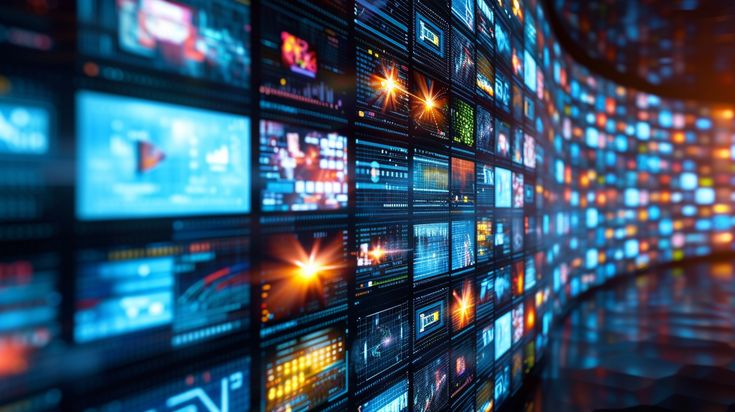


# **Autonomous Daily Tech News Agent**
**By Danah Alhamdi**

## Project Overview

This project builds an **autonomous AI agent** that collects current technology news from public RSS feeds, validates and analyzes the articles, identifies major trends, calculates an internal research quality score, stores articles in persistent vector memory, and generates a structured daily report with numbered citations and source links.

## Main Technologies

- **OpenRouter**: provides access to a free Large Language Model through one unified API
- **`openrouter/free`**: automatically routes each request to an available free model
- **LangGraph**: manages agents, shared state, conditional routing and retry loops
- **RSS feeds**: collect current news without requiring a separate search API key
- **ChromaDB**: stores articles in persistent vector memory
- **Google Drive**: preserves reports and vector memory after the Colab session ends

## Workflow Architecture

```text
START
  ↓
News Collection Agent
  ↓
Vector Memory Agent
  ↓
Validation and Analysis Agent
  ↓
Is the quality sufficient?
  ├── No  → Search again
  └── Yes → Report Generation Agent
                    ↓
              Save Report
                    ↓
                   END
```



## **Install Required Libraries**
This cell installs the libraries needed for:

- OpenRouter API calls
- LangGraph workflow
- ChromaDB vector memory
- RSS news collection
- Article date parsing

In [1]:
!pip install -q -U openai langgraph chromadb feedparser python-dateutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━

## **Restart Reminder**

After the installation finishes restart the Colab session once:

`Runtime → Restart session`

Then continue running the remaining cells in order.

In [2]:
print("Installation completed.")
print("Recommended: Runtime → Restart session, then continue from Cell 3.")

Installation completed.
Recommended: Runtime → Restart session, then continue from Cell 3.


## **Connect Google Drive**

Google Drive is used to save:

- ChromaDB persistent memory
- Generated reports
- Workflow outputs

This prevents the project data from disappearing when the Colab runtime closes.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


##  **Enter the OpenRouter API Key Securely**

The key is entered using `getpass`, so it does not appear in the notebook output.

The key should begin with:

`sk-or-v1-`

In [4]:
import os
from getpass import getpass

if not os.getenv("OPENROUTER_API_KEY"):
    os.environ["OPENROUTER_API_KEY"] = getpass(
        "Enter your OpenRouter API key: "
    )

print("OpenRouter API key was added to this Colab session.")

Enter your OpenRouter API key: ··········
OpenRouter API key was added to this Colab session.


##  **Imports and Project Configuration**

This cell defines:

- The free OpenRouter model router
- Minimum acceptable quality
- Minimum number of validated articles
- Maximum search attempts
- File storage paths

In [5]:
import os
import re
import json
import time
import hashlib
from datetime import datetime, timezone, timedelta
from typing import Any, Dict, List, Literal, TypedDict
from urllib.parse import quote_plus

import feedparser
import chromadb

from dateutil import parser as date_parser
from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from IPython.display import Markdown, display


# Specific free model selected through OpenRouter
OPENROUTER_MODEL = "nvidia/nemotron-3-ultra-550b-a55b:free"

QUALITY_THRESHOLD = 70
MINIMUM_VALIDATED_ARTICLES = 5
MAX_SEARCH_ITERATIONS = 2

BASE_PATH = "/content/drive/MyDrive/openrouter_daily_tech_agent"
CHROMA_PATH = f"{BASE_PATH}/chroma_db"
REPORTS_PATH = f"{BASE_PATH}/reports"

os.makedirs(CHROMA_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

print("Project configuration completed.")

Project configuration completed.


In [6]:
def test_openrouter_connection() -> None:
    try:
        response = openrouter_client.chat.completions.create(
            model=OPENROUTER_MODEL,
            messages=[
                {
                    "role": "user",
                    "content": "Reply with exactly: Nemotron connection successful"
                }
            ],
            temperature=0,
            max_tokens=50,
        )

        print(response.choices[0].message.content)
        print("Selected model:", response.model)

    except Exception as error:
        print("Connection failed:")
        print(error)


test_openrouter_connection()

Connection failed:
name 'openrouter_client' is not defined


## **Create OpenRouter and ChromaDB Clients**

OpenRouter uses an OpenAI-compatible API, so the OpenAI Python library can call it by changing the `base_url`.

ChromaDB creates a persistent collection that stores news articles semantically.

In [7]:
openrouter_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
    default_headers={
        "HTTP-Referer": "https://colab.research.google.com",
        "X-Title": "Autonomous Daily Tech News Agent",
    },
)

chroma_client = chromadb.PersistentClient(
    path=CHROMA_PATH
)

news_memory = chroma_client.get_or_create_collection(
    name="daily_technology_news",
    metadata={
        "description": "Persistent vector memory for technology news"
    },
)

print("OpenRouter and ChromaDB clients are ready.")

OpenRouter and ChromaDB clients are ready.


##  **Test the OpenRouter Connection**

This cell sends a very small request to confirm that:

- The API key is valid
- The free model router is available
- The account can make API requests

It also prints the actual free model selected by OpenRouter.

In [8]:
def test_openrouter_connection() -> None:
    try:
        response = openrouter_client.chat.completions.create(
            model=OPENROUTER_MODEL,
            messages=[
                {
                    "role": "user",
                    "content": "Reply with exactly: OpenRouter connection successful"
                }
            ],
            temperature=0,
            max_tokens=30,
        )

        print(response.choices[0].message.content)
        print("Selected model:", response.model)

    except Exception as error:
        print("OpenRouter connection failed:")
        print(error)


test_openrouter_connection()

OpenRouter connection successful
Selected model: nvidia/nemotron-3-ultra-550b-a55b:free


##  **Define the Shared LangGraph State**

The state is the shared memory passed between all agents.

It stores:

- Search queries
- Collected articles
- Validated articles
- Retrieved memory
- Technology trends
- Quality score
- Generated report
- Execution logs

In [9]:
class TechNewsState(TypedDict):
    user_query: str
    search_queries: List[str]

    collected_news: List[Dict[str, Any]]
    validated_news: List[Dict[str, Any]]
    memory_results: List[Dict[str, Any]]

    trending_topics: List[str]
    analysis_summary: str
    quality_score: float

    iteration: int
    max_iterations: int

    final_report: str
    report_file: str
    selected_model: str

    execution_logs: List[str]

## **General Helper Functions**

These helper functions:

- Create timestamped logs
- Clean text
- Generate stable article IDs
- Remove duplicates
- Parse JSON returned by the LLM
- Safely parse publication dates

In [10]:
def create_log(message: str) -> str:
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log = f"[{timestamp}] {message}"
    print(log)
    return log


def clean_text(text: Any) -> str:
    if text is None:
        return ""

    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def article_id(article: Dict[str, Any]) -> str:
    unique_value = (
        article.get("url")
        or article.get("title")
        or json.dumps(article, sort_keys=True)
    )

    return hashlib.sha256(
        unique_value.encode("utf-8")
    ).hexdigest()


def remove_duplicates(
    articles: List[Dict[str, Any]]
) -> List[Dict[str, Any]]:

    unique_articles: Dict[str, Dict[str, Any]] = {}

    for article in articles:
        url = clean_text(article.get("url", "")).lower()
        title = clean_text(article.get("title", "")).lower()
        key = url or title

        if key and key not in unique_articles:
            unique_articles[key] = article

    return list(unique_articles.values())


def parse_json_response(text: str) -> Dict[str, Any]:
    cleaned = text.strip()
    cleaned = cleaned.replace("```json", "")
    cleaned = cleaned.replace("```", "")
    cleaned = cleaned.strip()

    try:
        return json.loads(cleaned)

    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", cleaned, re.DOTALL)

        if not match:
            raise ValueError("The model did not return valid JSON.")

        return json.loads(match.group(0))


def safe_parse_date(value: str) -> str:
    if not value:
        return ""

    try:
        parsed = date_parser.parse(value)
        return parsed.astimezone(timezone.utc).isoformat()

    except Exception:
        return clean_text(value)

##  **RSS Search Function**

This project uses Google News RSS search to collect recent technology news without a separate search API key.

The function returns:

- Title
- Source URL
- Publication date
- RSS summary
- Search query

In [11]:
def search_google_news_rss(
    query: str,
    max_results: int = 8
) -> List[Dict[str, Any]]:

    encoded_query = quote_plus(query)

    rss_url = (
        "https://news.google.com/rss/search"
        f"?q={encoded_query}"
        "&hl=en-US"
        "&gl=US"
        "&ceid=US:en"
    )

    feed = feedparser.parse(rss_url)
    articles: List[Dict[str, Any]] = []

    for entry in feed.entries[:max_results]:
        source_name = ""

        if hasattr(entry, "source"):
            source_name = clean_text(
                entry.source.get("title", "")
            )

        articles.append({
            "title": clean_text(entry.get("title", "")),
            "url": clean_text(entry.get("link", "")),
            "content": clean_text(
                entry.get("summary", "")
            ),
            "published_date": safe_parse_date(
                entry.get("published", "")
            ),
            "source_name": source_name,
            "search_query": query,
        })

    return articles

## **Agent 1: News Collection Agent**

This agent searches for recent news across several technology categories.

If the quality is insufficient, LangGraph sends the workflow back to this agent and it uses a second set of search queries.

In [12]:
def news_collection_agent(
    state: TechNewsState
) -> Dict[str, Any]:

    logs = list(state.get("execution_logs", []))
    iteration = state.get("iteration", 0) + 1

    logs.append(
        create_log(
            f"News Collection Agent started — iteration {iteration}."
        )
    )

    today = datetime.now(timezone.utc).strftime("%Y-%m-%d")

    if iteration == 1:
        search_queries = [
            f"artificial intelligence technology news when:1d {today}",
            f"cybersecurity technology news when:1d {today}",
            f"robotics technology news when:1d {today}",
            f"cloud computing technology news when:1d {today}",
            f"semiconductor technology news when:1d {today}",
        ]

    else:
        search_queries = [
            f"breaking technology industry news when:2d {today}",
            f"AI product launch news when:2d {today}",
            f"technology startup funding news when:2d {today}",
            f"software engineering trends news when:2d {today}",
            f"digital transformation news when:2d {today}",
        ]

    newly_collected: List[Dict[str, Any]] = []

    for query in search_queries:
        try:
            results = search_google_news_rss(
                query=query,
                max_results=6
            )

            newly_collected.extend(results)

            logs.append(
                create_log(
                    f"RSS query returned {len(results)} results: {query}"
                )
            )

        except Exception as error:
            logs.append(
                create_log(
                    f"RSS search failed for '{query}': {error}"
                )
            )

    previous_news = state.get("collected_news", [])

    all_news = remove_duplicates(
        previous_news + newly_collected
    )

    logs.append(
        create_log(
            f"{len(all_news)} unique articles are available."
        )
    )

    return {
        "search_queries": search_queries,
        "collected_news": all_news,
        "iteration": iteration,
        "execution_logs": logs,
    }

## **Agent 2: Persistent Vector Memory Agent**

This agent stores each article in ChromaDB.

ChromaDB automatically creates embeddings using its local default embedding model so no additional paid embedding API is required.

The agent also retrieves articles semantically related to the project query.

In [13]:
def vector_memory_agent(
    state: TechNewsState
) -> Dict[str, Any]:

    logs = list(state.get("execution_logs", []))

    logs.append(
        create_log("Persistent Vector Memory Agent started.")
    )

    articles = state.get("collected_news", [])

    ids: List[str] = []
    documents: List[str] = []
    metadatas: List[Dict[str, Any]] = []

    for article in articles:
        title = clean_text(article.get("title", ""))
        content = clean_text(article.get("content", ""))
        url = clean_text(article.get("url", ""))

        if not title or not url:
            continue

        document_text = (
            f"Title: {title}\n"
            f"Source: {article.get('source_name', '')}\n"
            f"Published: {article.get('published_date', '')}\n"
            f"Summary: {content or title}\n"
            f"URL: {url}"
        )

        ids.append(article_id(article))
        documents.append(document_text)

        metadatas.append({
            "title": title,
            "url": url,
            "source_name": clean_text(
                article.get("source_name", "")
            ),
            "published_date": clean_text(
                article.get("published_date", "")
            ),
            "stored_at": datetime.now(
                timezone.utc
            ).isoformat(),
        })

    if documents:
        news_memory.upsert(
            ids=ids,
            documents=documents,
            metadatas=metadatas,
        )

    memory_results: List[Dict[str, Any]] = []
    stored_count = news_memory.count()

    if stored_count > 0:
        number_to_retrieve = min(10, stored_count)

        results = news_memory.query(
            query_texts=[
                state.get(
                    "user_query",
                    "latest technology news and trends"
                )
            ],
            n_results=number_to_retrieve,
            include=[
                "documents",
                "metadatas",
                "distances",
            ],
        )

        documents_result = results.get(
            "documents",
            [[]]
        )[0]

        metadata_result = results.get(
            "metadatas",
            [[]]
        )[0]

        distances_result = results.get(
            "distances",
            [[]]
        )[0]

        for document, metadata, distance in zip(
            documents_result,
            metadata_result,
            distances_result,
        ):
            memory_results.append({
                "document": document,
                "title": metadata.get("title", ""),
                "url": metadata.get("url", ""),
                "source_name": metadata.get(
                    "source_name",
                    ""
                ),
                "published_date": metadata.get(
                    "published_date",
                    ""
                ),
                "distance": distance,
            })

    logs.append(
        create_log(
            f"Vector memory contains {stored_count} stored articles."
        )
    )

    logs.append(
        create_log(
            f"Retrieved {len(memory_results)} semantically relevant items."
        )
    )

    return {
        "memory_results": memory_results,
        "execution_logs": logs,
    }

##  **OpenRouter LLM Helper**

This function sends a prompt to OpenRouter using the free model router.

It also returns the actual free model selected for that request.

In [14]:
def call_openrouter(
    prompt: str,
    temperature: float = 0.2,
    max_tokens: int = 2500,
) -> tuple[str, str]:

    response = openrouter_client.chat.completions.create(
        model=OPENROUTER_MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a careful technology research assistant. "
                    "Use only the supplied evidence and never invent sources."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        temperature=temperature,
        max_tokens=max_tokens,
    )

    content = response.choices[0].message.content or ""

    return content.strip(), response.model

## **Agent 3: Validation and Analysis Agent**

This agent asks the LLM to:

- Select the strongest and most relevant articles
- Remove weak or duplicate items
- Identify technology trends
- Generate a short analytical summary
- Calculate an internal quality score

The LLM must return JSON so the workflow can use the result programmatically.

In [15]:
def validation_analysis_agent(
    state: TechNewsState
) -> Dict[str, Any]:

    logs = list(state.get("execution_logs", []))

    logs.append(
        create_log("Validation and Analysis Agent started.")
    )

    collected_news = remove_duplicates(
        state.get("collected_news", [])
    )

    candidate_news = [
        article
        for article in collected_news
        if article.get("title")
        and article.get("url")
    ][:20]

    if not candidate_news:
        logs.append(
            create_log("No candidate articles were available.")
        )

        return {
            "validated_news": [],
            "trending_topics": [],
            "analysis_summary": (
                "No sufficient articles were available."
            ),
            "quality_score": 0,
            "selected_model": "",
            "execution_logs": logs,
        }

    articles_text = "\n\n".join(
        [
            (
                f"ARTICLE NUMBER: {index + 1}\n"
                f"TITLE: {article.get('title', '')}\n"
                f"SOURCE: {article.get('source_name', '')}\n"
                f"PUBLISHED: {article.get('published_date', '')}\n"
                f"SUMMARY: {article.get('content', '')}\n"
                f"URL: {article.get('url', '')}"
            )
            for index, article in enumerate(
                candidate_news
            )
        ]
    )

    prompt = f'''
Analyze only the technology news articles supplied below.

Tasks:
1. Select the most relevant and credible articles.
2. Exclude duplicate, weak, promotional, or irrelevant stories.
3. Identify up to five current technology trends.
4. Write a concise analytical summary.
5. Assign an internal research quality score from 0 to 100.

Score dimensions:
- Recency: 25 points
- Source diversity: 20 points
- Relevance: 25 points
- Number of useful articles: 15 points
- Consistency across sources: 15 points

Return valid JSON only:
{{
  "accepted_article_numbers": [1, 2, 3],
  "trending_topics": ["Trend one", "Trend two"],
  "analysis_summary": "Short analytical summary",
  "quality_score": 80
}}

Do not include markdown.
Do not invent facts or sources.

ARTICLES:
{articles_text}
'''

    try:
        response_text, selected_model = call_openrouter(
            prompt=prompt,
            temperature=0.1,
            max_tokens=1800,
        )

        result = parse_json_response(response_text)

        accepted_numbers = result.get(
            "accepted_article_numbers",
            []
        )

        validated_news: List[Dict[str, Any]] = []

        for number in accepted_numbers:
            try:
                index = int(number) - 1

                if 0 <= index < len(candidate_news):
                    validated_news.append(
                        candidate_news[index]
                    )

            except (TypeError, ValueError):
                continue

        if not validated_news:
            validated_news = candidate_news[:10]

        quality_score = max(
            0,
            min(
                100,
                float(result.get("quality_score", 0))
            )
        )

        trending_topics = result.get(
            "trending_topics",
            []
        )

        analysis_summary = clean_text(
            result.get("analysis_summary", "")
        )

        logs.append(
            create_log(
                f"OpenRouter selected model: {selected_model}"
            )
        )

    except Exception as error:
        validated_news = candidate_news[:8]
        trending_topics = []
        analysis_summary = (
            "The automated LLM analysis failed, so the "
            "available articles were retained as a fallback."
        )
        quality_score = 40
        selected_model = ""

        logs.append(
            create_log(
                f"Validation analysis failed: {error}"
            )
        )

    logs.append(
        create_log(
            f"Validated {len(validated_news)} articles."
        )
    )

    logs.append(
        create_log(
            f"Research quality score: {quality_score}/100."
        )
    )

    return {
        "validated_news": validated_news,
        "trending_topics": trending_topics,
        "analysis_summary": analysis_summary,
        "quality_score": quality_score,
        "selected_model": selected_model,
        "execution_logs": logs,
    }

##  **Conditional Routing Function**

This function creates the autonomous decision.

The workflow generates the report when:

- Quality score is at least 70
- At least five articles were validated

Otherwise, it returns to the News Collection Agent until the maximum number of attempts is reached.

In [16]:
def route_after_analysis(
    state: TechNewsState
) -> Literal["search_again", "generate_report"]:

    quality_score = state.get("quality_score", 0)

    validated_count = len(
        state.get("validated_news", [])
    )

    iteration = state.get("iteration", 0)

    max_iterations = state.get(
        "max_iterations",
        MAX_SEARCH_ITERATIONS
    )

    quality_is_sufficient = (
        quality_score >= QUALITY_THRESHOLD
        and validated_count
        >= MINIMUM_VALIDATED_ARTICLES
    )

    if quality_is_sufficient:
        return "generate_report"

    if iteration >= max_iterations:
        return "generate_report"

    return "search_again"

## **Agent 4: Report Generation Agent**

This agent produces the final technology intelligence report.

The report includes:

- Executive summary
- Top news
- Why each story matters
- Trending topics
- AI-generated analysis
- Quality score
- Limitations
- Numbered references
- Read-more links

In [17]:
def report_generation_agent(
    state: TechNewsState
) -> Dict[str, Any]:

    logs = list(state.get("execution_logs", []))

    logs.append(
        create_log("Report Generation Agent started.")
    )

    articles = state.get(
        "validated_news",
        []
    )[:10]

    quality_score = state.get(
        "quality_score",
        0
    )

    analysis_summary = state.get(
        "analysis_summary",
        ""
    )

    trends = state.get(
        "trending_topics",
        []
    )

    if not articles:
        report = (
            "# Daily Technology Intelligence Brief\n\n"
            "No validated articles were available."
        )

        return {
            "final_report": report,
            "execution_logs": logs,
        }

    sources_text = "\n\n".join(
        [
            (
                f"SOURCE [{index}]\n"
                f"Title: {article.get('title', '')}\n"
                f"Source: {article.get('source_name', '')}\n"
                f"Published: {article.get('published_date', '')}\n"
                f"Summary: {article.get('content', '')}\n"
                f"URL: {article.get('url', '')}"
            )
            for index, article in enumerate(
                articles,
                start=1
            )
        ]
    )

    trends_text = "\n".join(
        f"- {trend}"
        for trend in trends
    )

    prompt = f'''
Create a professional daily technology intelligence report
using only the supplied sources.

Use exactly this structure:

# Daily Technology Intelligence Brief

## Executive Summary

## Top Technology News

For each selected story:
### Headline
Write a concise 2-3 sentence summary and cite the supplied
source using [1], [2], and so on.
**Why it matters:** one concise explanation.
**Read more:** exact original URL

## Trending Topics

## AI-Generated Analysis

## Key Takeaway

## Research Quality Score

## Limitations

## References
[number] Title — URL

Rules:
- Every factual claim must have a numbered citation.
- Do not invent information.
- Do not invent or change URLs.
- Use only the supplied sources.
- The quality score is an internal workflow score, not a guarantee.
- Keep the report clear and concise.

Internal quality score:
{quality_score}/100

Previous analytical summary:
{analysis_summary}

Detected trends:
{trends_text}

Sources:
{sources_text}
'''

    try:
        final_report, report_model = call_openrouter(
            prompt=prompt,
            temperature=0.2,
            max_tokens=3500,
        )

        logs.append(
            create_log(
                f"Report generated using model: {report_model}"
            )
        )

        selected_model = (
            state.get("selected_model")
            or report_model
        )

    except Exception as error:
        selected_model = state.get(
            "selected_model",
            ""
        )

        final_report = (
            "# Daily Technology Intelligence Brief\n\n"
            f"Report generation failed: {error}"
        )

        logs.append(
            create_log(
                f"Report generation failed: {error}"
            )
        )

    return {
        "final_report": final_report,
        "selected_model": selected_model,
        "execution_logs": logs,
    }

##  **Agent 5: Save the Report**

This agent saves the final report as a Markdown file in Google Drive.

Each report receives a unique date and time in its filename.

In [18]:
def save_report_agent(
    state: TechNewsState
) -> Dict[str, Any]:

    logs = list(state.get("execution_logs", []))

    logs.append(
        create_log("Report Saving Agent started.")
    )

    timestamp = datetime.now().strftime(
        "%Y-%m-%d_%H-%M-%S"
    )

    report_file = (
        f"{REPORTS_PATH}/"
        f"technology_brief_{timestamp}.md"
    )

    with open(
        report_file,
        "w",
        encoding="utf-8"
    ) as file:
        file.write(
            state.get("final_report", "")
        )

    logs.append(
        create_log(
            f"Report saved to: {report_file}"
        )
    )

    return {
        "report_file": report_file,
        "execution_logs": logs,
    }

##  **Build the LangGraph Workflow**

Each function becomes a node.

The conditional edge decides whether the workflow should:

- Search again
- Generate the final report

In [19]:
builder = StateGraph(TechNewsState)

builder.add_node(
    "news_collector",
    news_collection_agent
)

builder.add_node(
    "vector_memory",
    vector_memory_agent
)

builder.add_node(
    "validator_analyzer",
    validation_analysis_agent
)

builder.add_node(
    "report_generator",
    report_generation_agent
)

builder.add_node(
    "report_saver",
    save_report_agent
)


builder.add_edge(
    START,
    "news_collector"
)

builder.add_edge(
    "news_collector",
    "vector_memory"
)

builder.add_edge(
    "vector_memory",
    "validator_analyzer"
)

builder.add_conditional_edges(
    "validator_analyzer",
    route_after_analysis,
    {
        "search_again": "news_collector",
        "generate_report": "report_generator",
    },
)

builder.add_edge(
    "report_generator",
    "report_saver"
)

builder.add_edge(
    "report_saver",
    END
)


tech_news_graph = builder.compile()

print("LangGraph workflow compiled successfully.")

LangGraph workflow compiled successfully.


##  **Create the Initial State and Run the Agent**

This function creates the initial state and invokes the entire autonomous workflow.

In [20]:
def run_daily_tech_agent() -> Dict[str, Any] | None:

    print("=" * 75)
    print("AUTONOMOUS DAILY TECH NEWS AGENT")
    print("=" * 75)

    initial_state: TechNewsState = {
        "user_query": (
            "Find and analyze the most important "
            "technology news and trends from the last 24 hours."
        ),

        "search_queries": [],

        "collected_news": [],
        "validated_news": [],
        "memory_results": [],

        "trending_topics": [],
        "analysis_summary": "",
        "quality_score": 0,

        "iteration": 0,
        "max_iterations": MAX_SEARCH_ITERATIONS,

        "final_report": "",
        "report_file": "",
        "selected_model": "",

        "execution_logs": [],
    }

    try:
        result = tech_news_graph.invoke(
            initial_state,
            config={
                "recursion_limit": 20
            },
        )

        print("\nWorkflow completed successfully.")

        return result

    except Exception as error:
        print("\nWorkflow failed:")
        print(error)

        return None



This is the main demonstration cell.

Run it to collect, analyze, store and report current technology news.

In [21]:
result = run_daily_tech_agent()

AUTONOMOUS DAILY TECH NEWS AGENT
[2026-07-20 09:30:20] News Collection Agent started — iteration 1.
[2026-07-20 09:30:20] RSS query returned 6 results: artificial intelligence technology news when:1d 2026-07-20
[2026-07-20 09:30:21] RSS query returned 6 results: cybersecurity technology news when:1d 2026-07-20
[2026-07-20 09:30:21] RSS query returned 6 results: robotics technology news when:1d 2026-07-20
[2026-07-20 09:30:22] RSS query returned 6 results: cloud computing technology news when:1d 2026-07-20
[2026-07-20 09:30:22] RSS query returned 6 results: semiconductor technology news when:1d 2026-07-20
[2026-07-20 09:30:22] 30 unique articles are available.
[2026-07-20 09:30:22] Persistent Vector Memory Agent started.


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:00<00:00, 93.4MiB/s]


[2026-07-20 09:30:31] Vector memory contains 30 stored articles.
[2026-07-20 09:30:31] Retrieved 10 semantically relevant items.
[2026-07-20 09:30:31] Validation and Analysis Agent started.
[2026-07-20 09:30:32] Validation analysis failed: 'NoneType' object is not subscriptable
[2026-07-20 09:30:32] Validated 8 articles.
[2026-07-20 09:30:32] Research quality score: 40/100.
[2026-07-20 09:30:32] News Collection Agent started — iteration 2.
[2026-07-20 09:30:32] RSS query returned 6 results: breaking technology industry news when:2d 2026-07-20
[2026-07-20 09:30:33] RSS query returned 6 results: AI product launch news when:2d 2026-07-20
[2026-07-20 09:30:33] RSS query returned 6 results: technology startup funding news when:2d 2026-07-20
[2026-07-20 09:30:33] RSS query returned 6 results: software engineering trends news when:2d 2026-07-20
[2026-07-20 09:30:34] RSS query returned 6 results: digital transformation news when:2d 2026-07-20
[2026-07-20 09:30:34] 56 unique articles are availa

## **Display the Final Report**

The final report is rendered as formatted Markdown inside Colab.

In [22]:
if result:
    display(
        Markdown(
            result.get(
                "final_report",
                "No report was generated."
            )
        )
    )

else:
    print("No result is available.")

# Daily Technology Intelligence Brief

## Executive Summary
Today's technology landscape shows continued global AI expansion across multiple sectors: Israel's high-tech sector demonstrates resilience amid conflict, China advances satellite AI applications, Senegal joins a new global AI cooperation body, Indonesia prepares copyright legislation targeting AI platforms, and legal AI tools gain recognition. Meanwhile, enterprise AI adoption strategies vary, with United Imaging Intelligence opting for measured rollout, while Türk Telekom strengthens cybersecurity partnerships.

## Top Technology News

### Israel's High-Tech Sector Shows Resilience Amid War and AI Disruption
Israel's high-technology sector continues to grow despite ongoing war, layoffs, and AI disruption, demonstrating remarkable adaptability in challenging conditions [1].
**Why it matters:** Highlights the resilience of innovation ecosystems under geopolitical stress and the dual impact of AI as both disruptor and growth driver.
**Read more:** https://news.google.com/rss/articles/CBMiswFBVV95cUxORXBGRnk3dFo5VWdlX2NLNVhrV2xvZEI5SGh1Z2FRbWd6ZTc0RGR1MnhkTTUyTElnRWNJUGRMYzlZZzh0V2NZTTU2UzNpNlMzZG9UQV9SeXU3OTJKeWgxWTYzRGVDRUdERmFBbXlPaU1lQzgzc0VYZmVQQXJ4WVhoT2xuNzhUcTVISzFpSlVqUjBWcHdNSVkyNElKOFZ2NnVwMzdDcGtRMFlnYjZkSWNiZERfbw?oc=5

### United Imaging Intelligence Adopts Measured AI Rollout Strategy
United Imaging Intelligence's co-CEO states the company is not pursuing an "extreme" AI rollout, indicating a deliberate, controlled approach to AI integration [2].
**Why it matters:** Reflects a growing trend of enterprises choosing strategic, risk-managed AI adoption over rapid, large-scale deployment.
**Read more:** https://news.google.com/rss/articles/CBMiqgFBVV95cUxOaXE4dWktQW5aOS11VW96MmVUaDU2MUFuZGJBa0Q5NXpDaF9XSXpxNW1jTXdncERvdXNZemhmcmNlS0hIRi1VbXhtM1NPMUF2SUxfUFRUdEVtTVRMN3VDZlJBUUlVTlFtbTA5T1duUW1nMFlwdHJUVjZkRDROQ3JjTEt6a1MxUGNYMXFSczhjenpXdmZjTnZ6ei0wRGlGNnpIdVZ6TG5xbnpUdw?oc=5

### Clarivate RiskMark Wins 2026 CODiE Award for Best AI Legal Tool
Clarivate's RiskMark platform received the 2026 CODiE Award for Best AI Tool for Lawyers, recognizing excellence in legal technology innovation [3].
**Why it matters:** Signals accelerating AI adoption in professional services and validates specialized legal AI solutions in competitive markets.
**Read more:** https://news.google.com/rss/articles/CBMiuwFBVV95cUxNdFBCanNId1NyRDVqY2hJWWRHUlI5c0lyWmwzNVFyRWNCZGJzTXlzZklrazR1cUpqXzVtY2FYcXhybkJCLUVmOVBlU251ekVRTDl6ZjB6dVZ5VUNSakowN1ozS1FrZWNmamt1LVVHbUhsaVZyN0xTWU9GaC1fOGNlVUlvMlR6LU9TbHI3aFlRZ1VoVkYxSzhMaEhlRVVrUTRlOTdwbjVCWnpfN1FHQ1Nsb1JMb1h3NGxRUjc0?oc=5

### China Releases AI Toolbox for Fengyun Satellite Applications
China's State Council Information Office announced an AI toolbox designed for Fengyun meteorological satellite applications, advancing space-based AI capabilities [4].
**Why it matters:** Demonstrates national investment in AI for earth observation and weather forecasting, with implications for climate monitoring and disaster response.
**Read more:** https://news.google.com/rss/articles/CBMif0FVX3lxTE5fQWJVMUZ6eHRmbjlybTVnTndTUENIdkd6ZFpkR29TSlJVZFp2YVdVYnJ0QjFjOWtwSm14OUkxeEp1Uks1YVgtMVZSUkJUSjAxdkNuTnhmQTk2NnRBSG9VeHpjWUctOGk1UFBBOEVGamZJMmZMeURDamNLVkdIbVE?oc=5

### Senegal Joins New Global AI Cooperation Organization
Senegal became a founding member of a new global artificial intelligence cooperation organization, marking African participation in international AI governance [5].
**Why it matters:** Expands geographic diversity in global AI collaboration frameworks and signals growing African engagement in shaping AI policy.
**Read more:** https://news.google.com/rss/articles/CBMizgFBVV95cUxQbmtNbDBxTURYRFVwVkFxckQ0V2pIVUtXSy1mRHFLUkJ6YkpXZktWVUZqYm9hVmhyWmswSzY1d2ZHcGVjSDVycXZuQUVvQklMM0pLOEY4RGMyNmZwLTZiR0xYcnhMSFdCNnlnQ0lOdWN0REo4UmZXeFhYdnBsQWxQMXI3UUZyRmhqTmRnTFdwTlRTakIxeWJMdDFvUEZHSEoteVFGZ1hFS1hMVVpLNkNaTy1IaXdiZF94ZUJIUG1rQkJNbW9JSzA1OWJaQUZuUQ?oc=5

### Indonesia Plans Copyright Law Targeting Google and AI Platforms
Indonesia's planned copyright legislation puts Google and AI platforms on notice, signaling regulatory scrutiny of AI training data and content usage [6].
**Why it matters:** Reflects emerging global trend of nations updating intellectual property frameworks to address AI-era challenges.
**Read more:** https://news.google.com/rss/articles/CBMi9AFBVV95cUxQeDhNVkgtSWdQd2RDUWR5YUZLSjUySFNmZmlRUk5RS1dTcHhZNklmUjhlWU5MbTAxMUNoekRtaDF0bVplM3lWUEVHVkFpeHBPTkswV2tnRnhhY2E4SDNqTHZEZE13NzhZNC1xQmJqR01STFIwLS1PZU9UdENSVnctUkhOcHE5V3BHWTNLeTNpQnVxbk5LSFFKNno4TzBSTi1JS3Qza1plNUd6RjlnVEJkcUUzbGtKWHNJVG9FVWVZTmtHUkFTQmpKa0RTVmkwY0JxaUpfUzdKYlhxc2VRQlZKd3lnMm4wM2d0WjRiT0c4ZG1jQjZU?oc=5

### Claude Mythos FAQ Details Capabilities and Competitive Landscape
CSO Online published a comprehensive FAQ on Claude Mythos covering capabilities, access, competitors, and implications for the AI assistant market [7].
**Why it matters:** Provides transparency on a major AI model's positioning and competitive dynamics in the foundation model ecosystem.
**Read more:** https://news.google.com/rss/articles/CBMirgFBVV95cUxOaE10YjdGU2JoM2xVRC02Q3VRQkVOX3ZBVmVMY1hXbTUxNDgwTUZ5OVBMUUdLdWNPcEtfYUZVMS0xaTRYMWFWckU2eUNuZ251VHV2aF9wcU5GNUtReHE3QUlYODdPU2ZTN3pfaDhHWG84Ti1GZV9IMC05QWNrUVNqZHg5OUY2TEExWmZuQURTMi1Tb1duVUpyTW5uVVZfa0RFRnRjQVBPRFpmekxHQlE?oc=5

### Türk Telekom Partners with CYBER ME Technology for Cybersecurity
Türk Telekom signed a strategic cybersecurity partnership with CYBER ME Technology, strengthening Turkey's telecommunications security infrastructure [8].
**Why it matters:** Highlights increasing telecom sector investment in specialized cybersecurity partnerships amid rising digital threats.
**Read more:** https://news.google.com/rss/articles/CBMiugFBVV95cUxORlFxekhEZjRxako4SkpyMjJXb2J4WWozTmlZV3lWYXpkMzdGRlFxNEhYbERnX25UdVlERFVBVUJtcmlLa3d4R3Bkbkhnaklic2dpQkZ0ekl2RzNuRG4tZklkVExwRV80emN0eTV6TWlyYzN0ZTlCVjlBMlBRX1lKTU1WeUlJTFl5UDh4VGdVSTEyNnpGd3RqZzNWdUlKTmRQRlNWejJobDFydkhfNGVjYjdQbjFLZmlXUFE?oc=5

## Trending Topics
- **AI Governance & International Cooperation**: Senegal's founding membership in global AI organization [5]
- **AI Regulatory Frameworks**: Indonesia's copyright law targeting AI platforms [6]
- **Enterprise AI Adoption Strategies**: Measured rollout vs. aggressive deployment [2]
- **Specialized AI Applications**: Legal tech (CODiE winner) [3], satellite meteorology [4]
- **Cybersecurity Partnerships**: Telecom sector strategic alliances [8]
- **Geopolitical Tech Resilience**: Israel's high-tech sector growth amid conflict [1]

## AI-Generated Analysis
The July 20, 2026 technology news cycle reveals three dominant patterns. First, **geographic diversification of AI governance** is accelerating, with Senegal joining a new global AI cooperation body [5] while Indonesia advances copyright legislation targeting AI platforms [6] — suggesting a multipolar regulatory landscape rather than unified global standards. Second, **enterprise AI strategies are bifurcating**: United Imaging Intelligence explicitly rejects "extreme" rollout [2], contrasting with sectors like legal tech where specialized tools (Clarivate RiskMark [3]) gain formal recognition. Third, **nation-state AI investment continues in strategic domains**: China's Fengyun satellite AI toolbox [4] and Israel's conflict-resilient high-tech growth [1] both demonstrate state-linked technological advancement despite different geopolitical contexts. The Türk Telekom cybersecurity partnership [8] further indicates critical infrastructure operators are prioritizing specialized security alliances. Collectively, these signals point to a maturing AI ecosystem where deployment philosophy, regulatory posture, and national strategic priorities are becoming key differentiators.

## Key Takeaway
AI development is fragmenting along three axes: regulatory (national copyright laws vs. international cooperation), deployment philosophy (measured vs. aggressive enterprise adoption), and strategic application (specialized professional tools vs. national infrastructure). Organizations must navigate this complexity rather than follow a single global playbook.

## Research Quality Score
40/100

## Limitations
- All sources are RSS feed summaries from Google News; full article content not accessible for deeper verification
- Limited to 8 sources from a single day (2026-07-20), preventing trend confirmation over time
- No primary source documents, financial data, or technical specifications available
- Source diversity concentrated in news aggregators rather than direct publications
- Cannot assess credibility of individual outlets beyond their stated identity

## References
[1] Israel's High-Tech Sector Grows Through War, Layoffs and AI Disruption — https://news.google.com/rss/articles/CBMiswFBVV95cUxORXBGRnk3dFo5VWdlX2NLNVhrV2xvZEI5SGh1Z2FRbWd6ZTc0RGR1MnhkTTUyTElnRWNJUGRMYzlZZzh0V2NZTTU2UzNpNlMzZG9UQV9SeXU3OTJKeWgxWTYzRGVDRUdERmFBbXlPaU1lQzgzc0VYZmVQQXJ4WVhoT2xuNzhUcTVISzFpSlVqUjBWcHdNSVkyNElKOFZ2NnVwMzdDcGtRMFlnYjZkSWNiZERfbw?oc=5
[2] United Imaging Intelligence not undertaking an "extreme" AI rollout, says co-CEO — https://news.google.com/rss/articles/CBMiqgFBVV95cUxOaXE4dWktQW5aOS11VW96MmVUaDU2MUFuZGJBa0Q5NXpDaF9XSXpxNW1jTXdncERvdXNZemhmcmNlS0hIRi1VbXhtM1NPMUF2SUxfUFRUdEVtTVRMN3VDZlJBUUlVTlFtbTA5T1duUW1nMFlwdHJUVjZkRDROQ3JjTEt6a1MxUGNYMX

## **Display the Workflow Summary**

This cell displays the most important project outputs.

In [23]:
if result:
    print(
        "Research Quality Score:",
        result.get("quality_score", 0),
        "/100"
    )

    print(
        "Search Iterations:",
        result.get("iteration", 0)
    )

    print(
        "Validated Articles:",
        len(
            result.get("validated_news", [])
        )
    )

    print(
        "OpenRouter Selected Model:",
        result.get("selected_model", "")
    )

    print(
        "Persistent Memory Articles:",
        news_memory.count()
    )

    print(
        "Saved Report:",
        result.get("report_file", "")
    )

Research Quality Score: 40 /100
Search Iterations: 2
Validated Articles: 8
OpenRouter Selected Model: nvidia/nemotron-3-ultra-550b-a55b:free
Persistent Memory Articles: 56
Saved Report: /content/drive/MyDrive/openrouter_daily_tech_agent/reports/technology_brief_2026-07-20_09-32-03.md


##  **Display Execution Logs**

The logs show:

- Agent execution order
- Search attempts
- Number of stored articles
- Quality score
- Model selected by OpenRouter
- Report save location

In [24]:
if result:
    print("EXECUTION LOGS")
    print("-" * 75)

    for log in result.get(
        "execution_logs",
        []
    ):
        print(log)

EXECUTION LOGS
---------------------------------------------------------------------------
[2026-07-20 09:30:20] News Collection Agent started — iteration 1.
[2026-07-20 09:30:20] RSS query returned 6 results: artificial intelligence technology news when:1d 2026-07-20
[2026-07-20 09:30:21] RSS query returned 6 results: cybersecurity technology news when:1d 2026-07-20
[2026-07-20 09:30:21] RSS query returned 6 results: robotics technology news when:1d 2026-07-20
[2026-07-20 09:30:22] RSS query returned 6 results: cloud computing technology news when:1d 2026-07-20
[2026-07-20 09:30:22] RSS query returned 6 results: semiconductor technology news when:1d 2026-07-20
[2026-07-20 09:30:22] 30 unique articles are available.
[2026-07-20 09:30:22] Persistent Vector Memory Agent started.
[2026-07-20 09:30:31] Vector memory contains 30 stored articles.
[2026-07-20 09:30:31] Retrieved 10 semantically relevant items.
[2026-07-20 09:30:31] Validation and Analysis Agent started.
[2026-07-20 09:30:32] 